# Generate Training Images (NS1024 + BubbleML)

This notebook generates two PNGs used in training visualization:
- `outputs/training_images/NS1024_training_frame_t100.png`
- `outputs/training_images/BubbleML_training_temperature_t40.png`

In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Resolve repository root from this notebook location.
repo_root = Path.cwd().resolve().parent
out_dir = repo_root / 'outputs' / 'training_images'
out_dir.mkdir(parents=True, exist_ok=True)

print('repo_root:', repo_root)
print('out_dir   :', out_dir)

repo_root: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE
out_dir   : /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/outputs/training_images


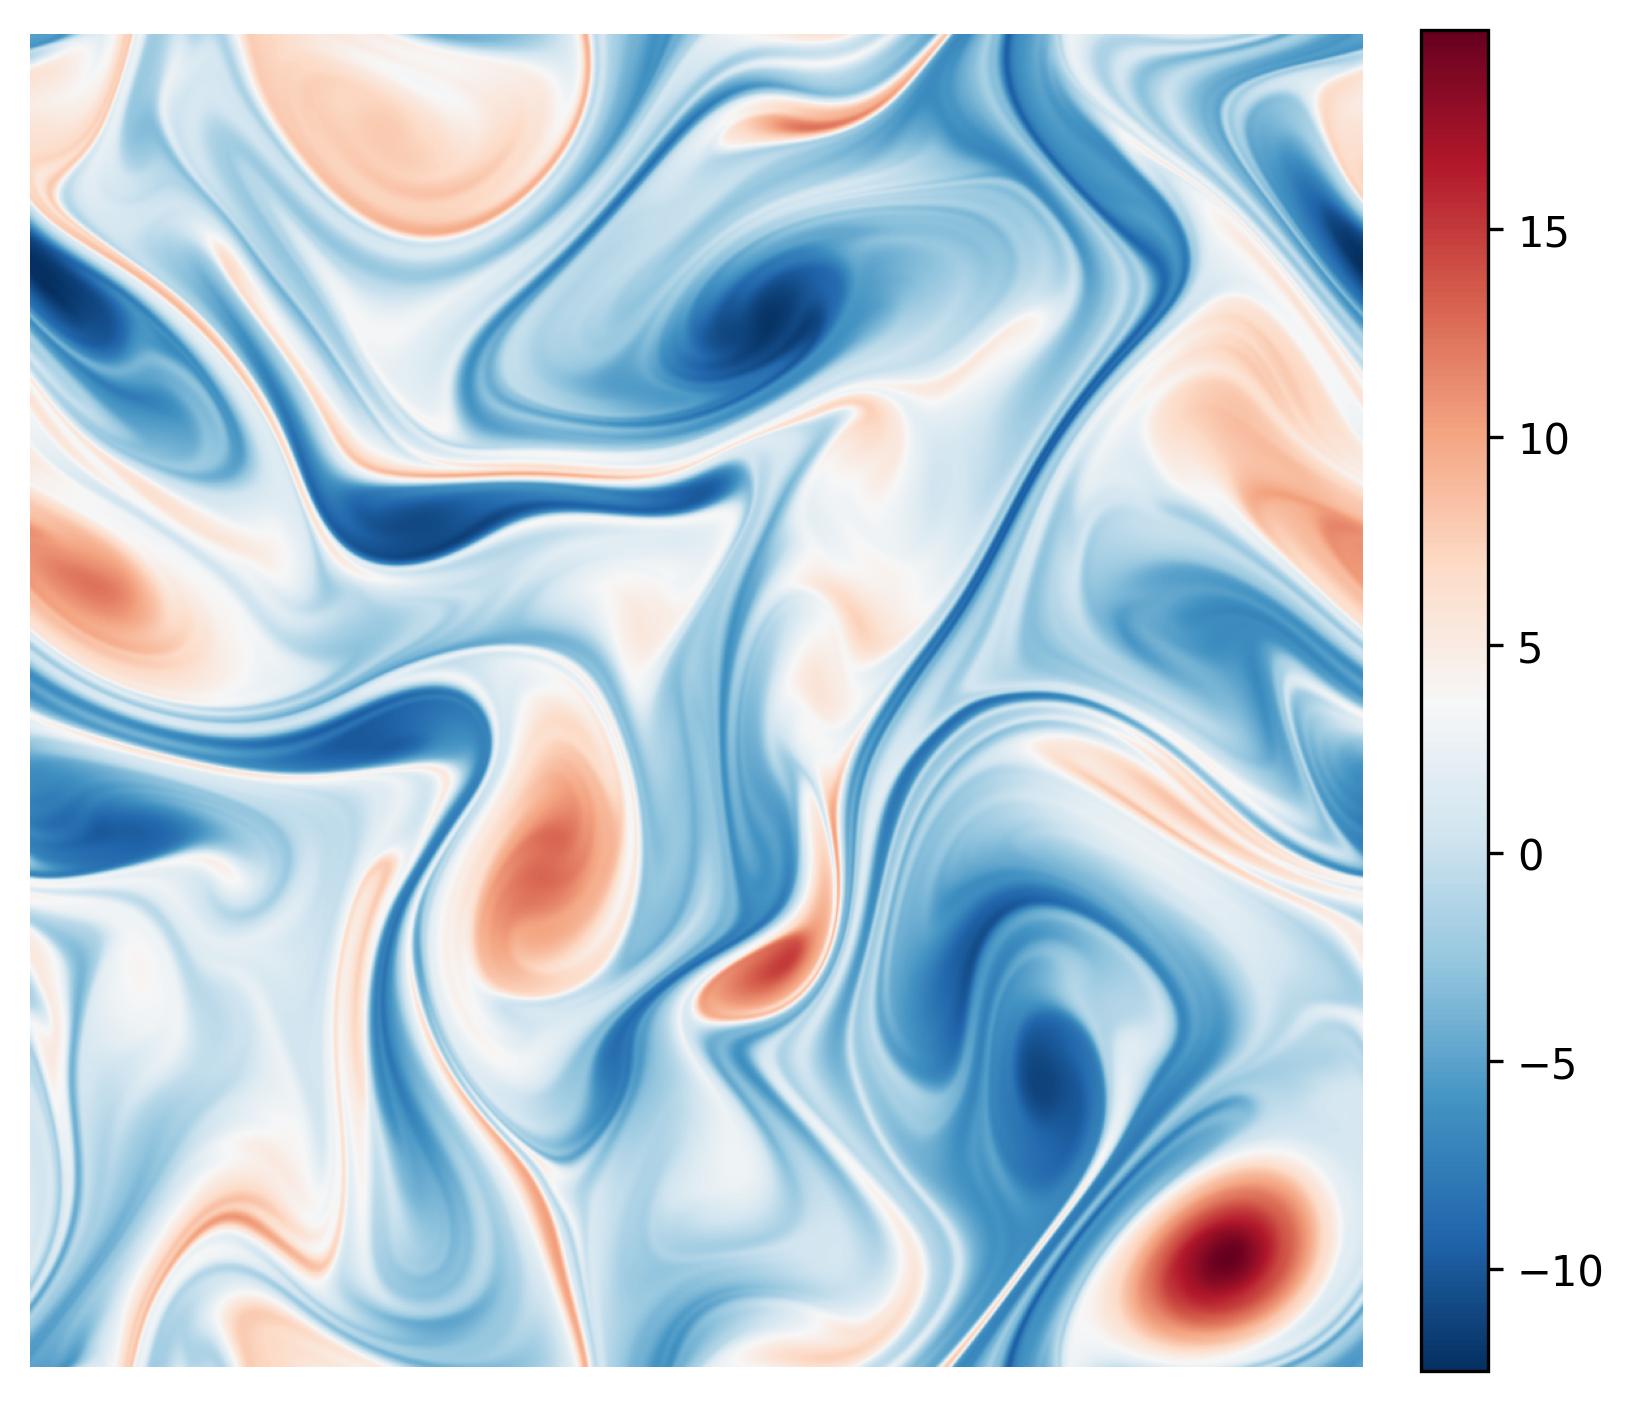

NS shape: (1, 250, 1024, 1024)
Saved   : /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figureNS1024_training_frame_t100.png


In [16]:
# NS image generation
ns_path = repo_root / 'data' / 'NS2d' / 'ns_data_res2048_re10000_7.npy'
ns_raw = np.load(ns_path)

if ns_raw.ndim != 4:
    raise ValueError(f'Unexpected NS tensor shape: {ns_raw.shape}')

# Expected layout in this repo: (N, T, H, W)
ns_sample_idx = 0
ns_time_idx = 100 if ns_raw.shape[1] > 100 else min(40, ns_raw.shape[1] - 1)
ns_img = ns_raw[ns_sample_idx, ns_time_idx]

ns_png = '/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figureNS1024_training_frame_t100.png'
plt.figure(figsize=(6, 6), dpi=300)
plt.imshow(ns_img, cmap='RdBu_r', origin='lower')
# plt.title(f'NS training frame (sample={ns_sample_idx}, t={ns_time_idx})')
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(ns_png)
plt.axis('off')
plt.show()
plt.close()

print('NS shape:', ns_raw.shape)
print('Saved   :', ns_png)

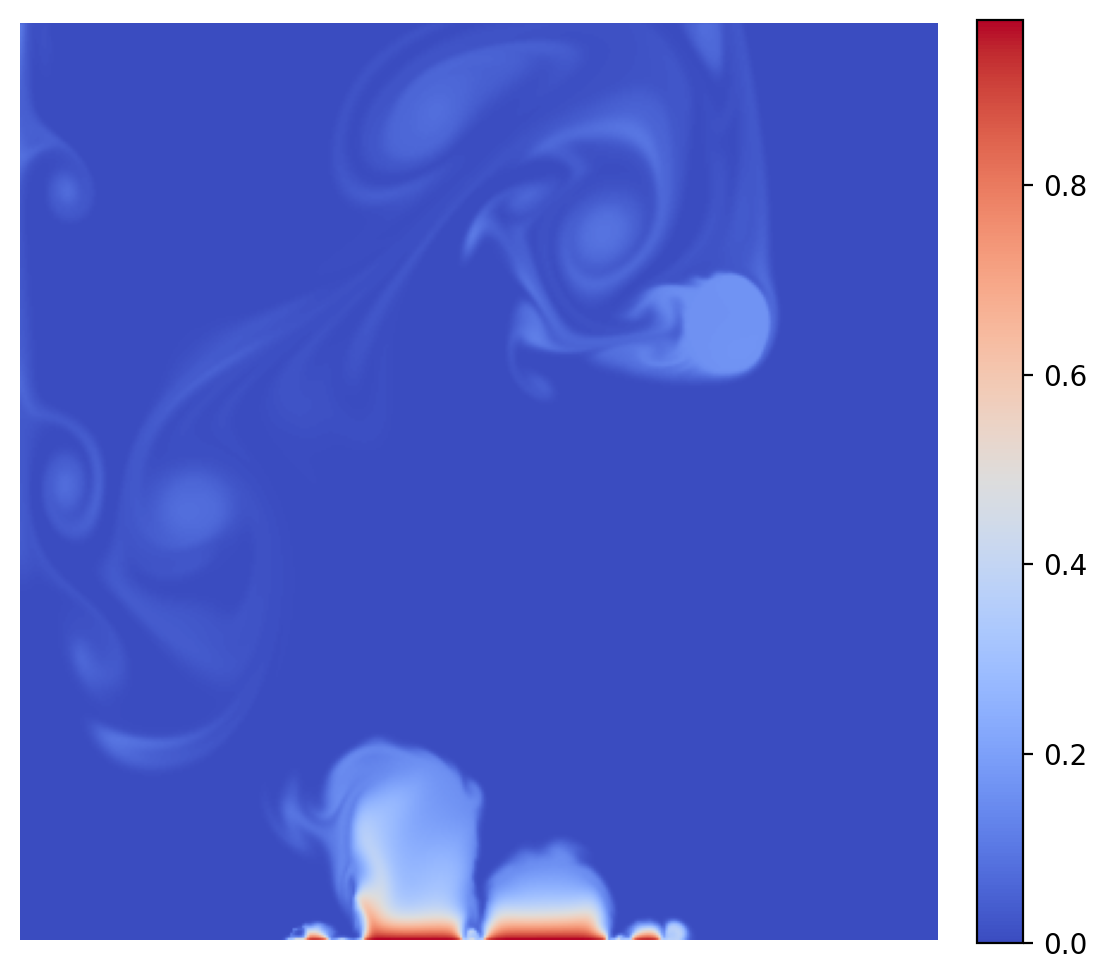

PoolBoiling shape: (201, 384, 384)
Saved           : /pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figureBubbleML_training_temperature_t40.png


In [18]:
# BubbleML (PoolBoiling) image generation
pb_path = repo_root / 'data' / 'PoolBoiling-SubCooled-FC72-2D' / 'Twall-100.hdf5'

with h5py.File(pb_path, 'r') as f:
    if 'temperature' not in f:
        raise KeyError(f"'temperature' not found. Keys: {list(f.keys())}")
    pb_raw = f['temperature'][:]

# Usually (T, H, W); handle (N, T, H, W) as fallback.
if pb_raw.ndim == 3:
    pb_time_idx = 40 if pb_raw.shape[0] > 40 else pb_raw.shape[0] - 1
    pb_img = pb_raw[pb_time_idx]
elif pb_raw.ndim == 4:
    pb_sample_idx = 0
    pb_time_idx = 40 if pb_raw.shape[1] > 40 else pb_raw.shape[1] - 1
    pb_img = pb_raw[pb_sample_idx, pb_time_idx]
else:
    raise ValueError(f'Unexpected PoolBoiling tensor shape: {pb_raw.shape}')

pb_png = '/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figureBubbleML_training_temperature_t40.png'
plt.figure(figsize=(6, 6), dpi=200)
plt.imshow(pb_img, cmap='coolwarm', origin='lower')
# plt.title(f'PoolBoiling temperature frame (t={pb_time_idx})')
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(pb_png)
plt.axis('off')
plt.show()
plt.close()

print('PoolBoiling shape:', pb_raw.shape)
print('Saved           :', pb_png)

In [ ]:
# Quick display check
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)
axes[0].imshow(plt.imread(ns_png))
axes[0].set_title('NS1024 PNG')
axes[0].axis('off')

axes[1].imshow(plt.imread(pb_png))
axes[1].set_title('BubbleML PNG')
axes[1].axis('off')

plt.tight_layout()
plt.show()